In [211]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, OrdinalEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
import time
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

**Initial Exploratory Data Analysis**

In [212]:
#loading data file
data_df = pd.read_csv('../data/BankChurners.csv')

In [213]:
data_df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [214]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

In [215]:
# Dropping the last two columns starting with Naive_ since they are not relavant for the data modeling
data_df = data_df.drop(columns=['Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'])

In [216]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

In [217]:
# Dropping CLIENTNUM column since it does not provide any real value from the functional prespective
data_df = data_df.drop(columns=['CLIENTNUM'])

In [218]:
data_df.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [219]:
# Exloring the data quality by checking the missing values in the columns
data_df.isnull().sum()

Attrition_Flag              0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64

**Observations on the missing data command output**


*   The data seems very clean with none of the columns having null (NaN) values
*   We will explore the individual categorical columns latter to see if the missing values are put in there own category


In [220]:
# Exploring the statistical summary of the dataset for the numeric columns.
data_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Customer_Age,10127.0,46.325960,8.016814,26.0,41.000,46.000,52.000,73.000
Dependent_count,10127.0,2.346203,1.298908,0.0,1.000,2.000,3.000,5.000
Months_on_book,10127.0,35.928409,7.986416,13.0,31.000,36.000,40.000,56.000
Total_Relationship_Count,10127.0,3.812580,1.554408,1.0,3.000,4.000,5.000,6.000
Months_Inactive_12_mon,10127.0,2.341167,1.010622,0.0,2.000,2.000,3.000,6.000
Contacts_Count_12_mon,10127.0,2.455317,1.106225,0.0,2.000,2.000,3.000,6.000
Credit_Limit,10127.0,8631.953698,9088.776650,1438.3,2555.000,4549.000,11067.500,34516.000
Total_Revolving_Bal,10127.0,1162.814061,814.987335,0.0,359.000,1276.000,1784.000,2517.000
Avg_Open_To_Buy,10127.0,7469.139637,9090.685324,3.0,1324.500,3474.000,9859.000,34516.000
Total_Amt_Chng_Q4_Q1,10127.0,0.759941,0.219207,0.0,0.631,0.736,0.859,3.397


**Observations based on the Output of .describe() method**


*   Data for Customer Age, Months_on_book seems be balanced at the center since both mean and median(50%) showing the values which are very close
*   Credit_Limit column sees to have more wider spread with std greater than the value of mean and almost the double of median. Also looking at the value for 75% quartile and max value for this column we can see a big difference which indicates some big outliers on the higher side of the credit limit which is pulling the mean to the higher value. Shows the data for this column is Right-Skewed
*   The same outlier issue mentioned in the point 2 also seems to be for Avg_Open_To_Buy column. Mean is more than double the median with very high std indicating big outliers on the higher side. Shows the data for this column to be Right-Skewed.
* Some amount of Right-Skewness can be seen for Total_Trans_Amt column also and looking at the 75% quartile value and max value shows a big difference indicating the presence of big outlier.
*  The rest of columns shows by large normal distribution and does not indicate any unusual skewness of data to left or right.



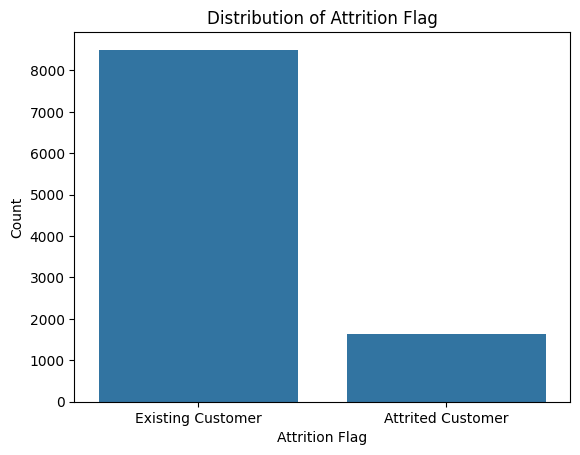

In [221]:
# Exploring the distribution of data for the target variable Attrition_Flag
sns.countplot(x='Attrition_Flag', data=data_df)
plt.xlabel('Attrition Flag')
plt.ylabel('Count')
plt.title('Distribution of Attrition Flag')
plt.show()

In [222]:
# Exploring the distribution of target variable Attrition_Flag in terms of percentage of class
data_df['Attrition_Flag'].value_counts(normalize=True)

Attrition_Flag
Existing Customer    0.83934
Attrited Customer    0.16066
Name: proportion, dtype: float64

**Observations on the Distribution of data for classes in the target variable Attrition_Flag**


*   The data seems be very imbalanced between the two classes 'Existing Customer and 'Attrited customer'
*   Existing Customers account for almost 84% of the data and Attrited Customer for the remaning 16%
* This is very important observation since we will need to configure the models to account for this imbalance in the class distribution and also to pick the metrics for the evaluation of the results.



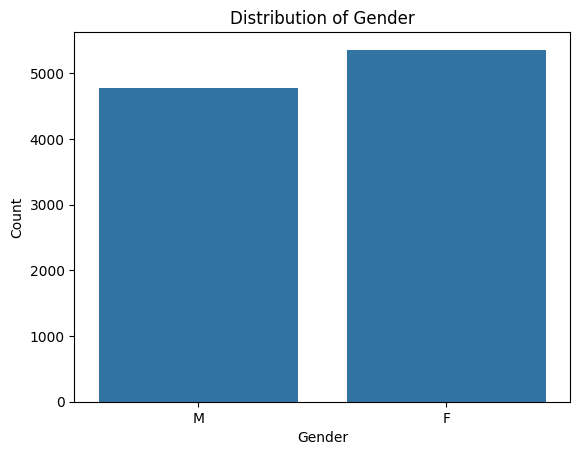

In [223]:
# Exploring the data distrbution for the Gender categorical column
sns.countplot(x='Gender', data=data_df)
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Distribution of Gender')
plt.show()

In [224]:
#Exploring the min and max value in the Customer_Age column
print(data_df['Customer_Age'].min())
print(data_df['Customer_Age'].max())

26
73


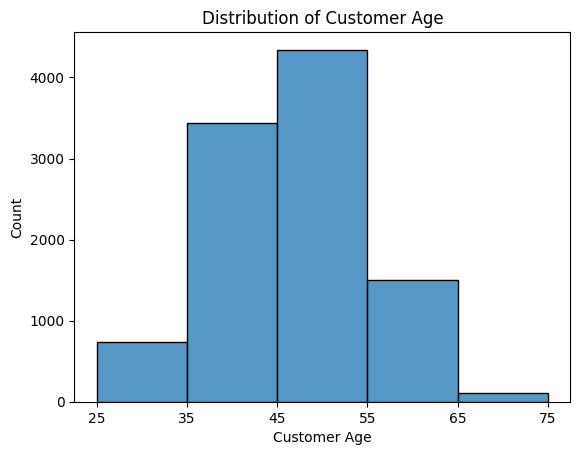

In [225]:
#Exploring the Customer Age distribution defining the custom bin range based on the min and max age value found in the column
sns.histplot(x='Customer_Age',
             binrange=(25, 75),
             binwidth=10,
             data=data_df)
plt.xticks(range(25, 76, 10))
plt.xlabel('Customer Age')
plt.ylabel('Count')
plt.title('Distribution of Customer Age')
plt.show()

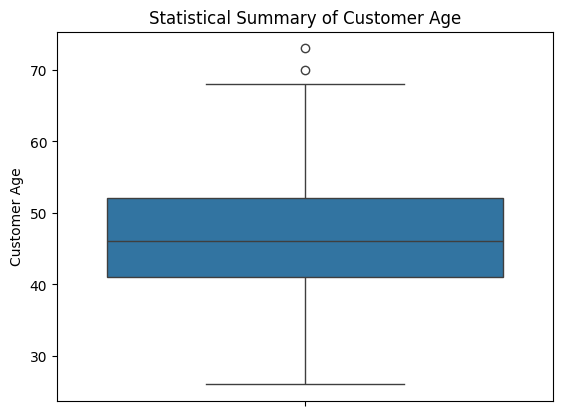

In [226]:
# Exploring th distribution of data by drawing box plot for Customer_Age column to check for data center and outliers
sns.boxplot(y=data_df['Customer_Age'])
plt.ylabel('Customer Age')
plt.title('Statistical Summary of Customer Age')
plt.show()

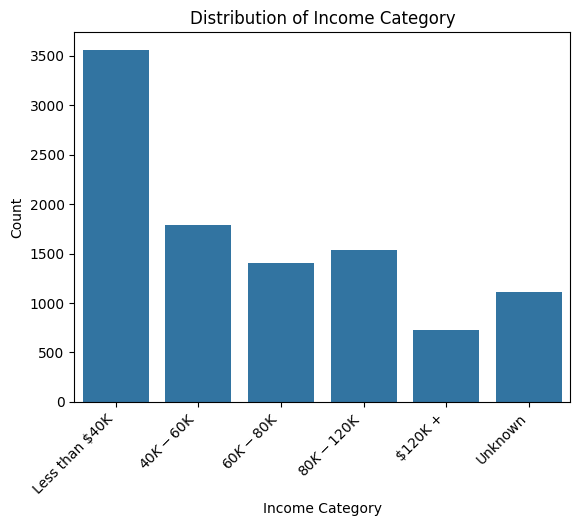

In [227]:
# Exploring distribution of data across the income range from lowest to highest
custom_order = ['Less than $40K', '$40K - $60K', '$60K - $80K', '$80K - $120K', '$120K +', 'Unknown']
sns.countplot(x='Income_Category', data=data_df, order=custom_order)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Income Category')
plt.ylabel('Count')
plt.title('Distribution of Income Category')
plt.show()

In [228]:
# Exploring the distribution of values in Income Category in percentage terms
data_df['Income_Category'].value_counts(normalize=True)

Income_Category
Less than $40K    0.351634
$40K - $60K       0.176755
$80K - $120K      0.151575
$60K - $80K       0.138442
Unknown           0.109805
$120K +           0.071788
Name: proportion, dtype: float64

**Observation**

*   In the Income category we see the category Unknown, which seems to be created for the missing data for which either the customers didn't disclose or was lost somewhere in the data processing.
*   The above data shows an amost 11% of the values in this column are Unknown. Since this is a substantial number we will need to find a strategy to impute value for Unknown Income category.
* We will discuss options for this as part of feature engineering exercise later in this project



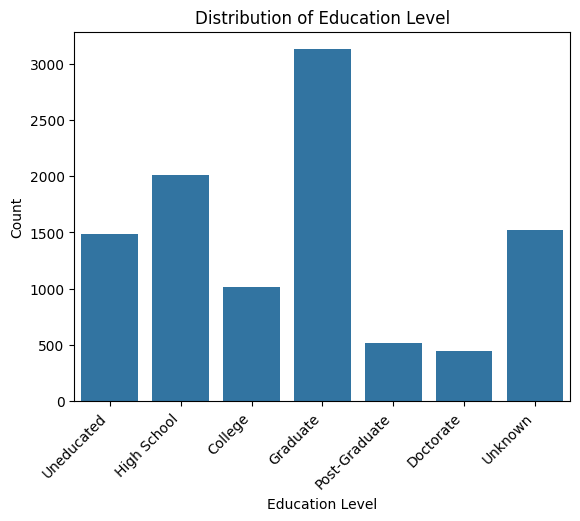

In [229]:
# Exploring the distribution of value for the Education level column
custom_order = ['Uneducated', 'High School', 'College', 'Graduate', 'Post-Graduate', 'Doctorate', 'Unknown']
sns.countplot(x='Education_Level', data=data_df , order=custom_order)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.title('Distribution of Education Level')
plt.show()

In [230]:
data_df['Education_Level'].value_counts(normalize=True)

Education_Level
Graduate         0.308877
High School      0.198776
Unknown          0.149995
Uneducated       0.146835
College          0.100030
Post-Graduate    0.050953
Doctorate        0.044534
Name: proportion, dtype: float64

**Observation**

The Education Level column shows the category Unknown. We will discuss options for this as part of feature engineering exercise later in this project

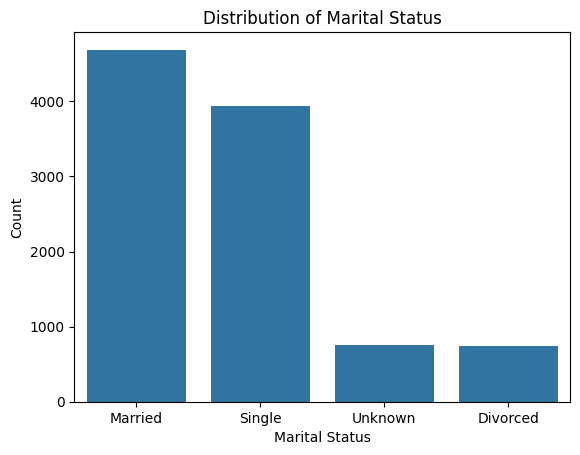

In [231]:
# Exploring the distribution of value for the Marital Status column
sns.countplot(x='Marital_Status', data=data_df)
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.title('Distribution of Marital Status')
plt.show()

In [232]:
data_df['Marital_Status'].value_counts(normalize=True)

Marital_Status
Married     0.462822
Single      0.389355
Unknown     0.073961
Divorced    0.073862
Name: proportion, dtype: float64

**Observation**

The Marital Status column shows the category Unknown. We will discuss options for this as part of feature engineering exercise later in this project

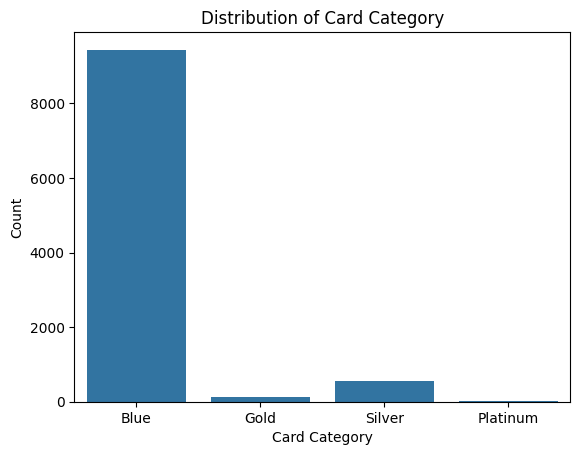

In [233]:
# Exploring the distribution of Card Category data
sns.countplot(x='Card_Category', data=data_df)
plt.xlabel('Card Category')
plt.ylabel('Count')
plt.title('Distribution of Card Category')
plt.show()

In [234]:
data_df['Card_Category'].value_counts(normalize=True)

Card_Category
Blue        0.931767
Silver      0.054804
Gold        0.011455
Platinum    0.001975
Name: proportion, dtype: float64

In [235]:
data_df['Card_Category'].value_counts()

Card_Category
Blue        9436
Silver       555
Gold         116
Platinum      20
Name: count, dtype: int64

In [236]:
# Calculatin the median for credit limit for each Card Category
data_df.groupby('Card_Category')['Credit_Limit'].median()

Card_Category
Blue         4105.0
Gold        34516.0
Platinum    34516.0
Silver      29808.0
Name: Credit_Limit, dtype: float64

<Axes: xlabel='Card_Category', ylabel='Credit_Limit'>

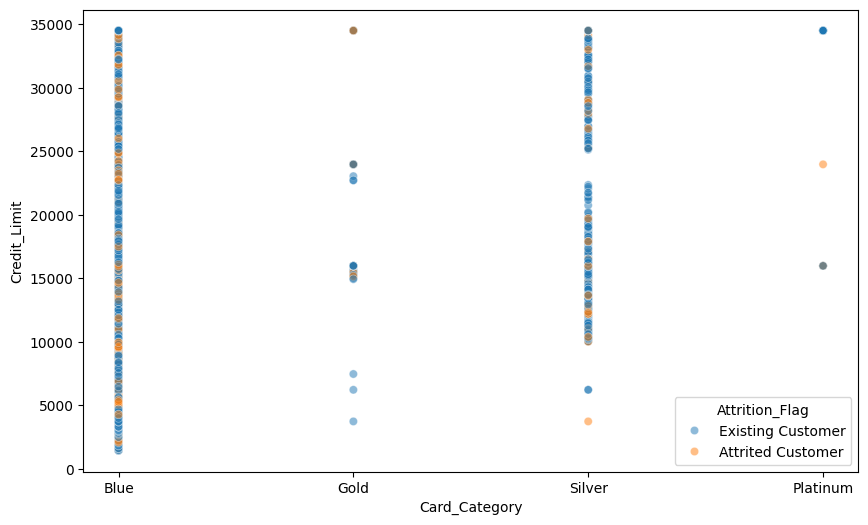

In [237]:
# Exploring the relationship between Total Txn Count and Total Transaction Amount features for the existing and attrited customers.
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data_df, x='Card_Category', y='Credit_Limit', hue='Attrition_Flag', alpha=0.5)

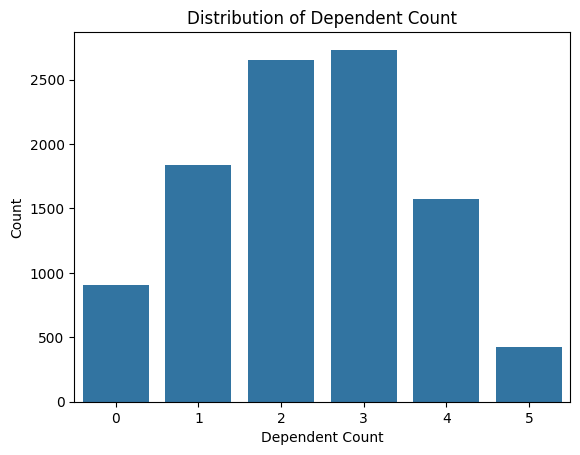

In [238]:
# Exploring the distribution of Dependent Count
sns.countplot(x='Dependent_count', data=data_df)
plt.xlabel('Dependent Count')
plt.ylabel('Count')
plt.title('Distribution of Dependent Count')
plt.show()

In [239]:
# Exploring Min and Max for the Months_on_book column
print(data_df['Months_on_book'].min())
print(data_df['Months_on_book'].max())

13
56


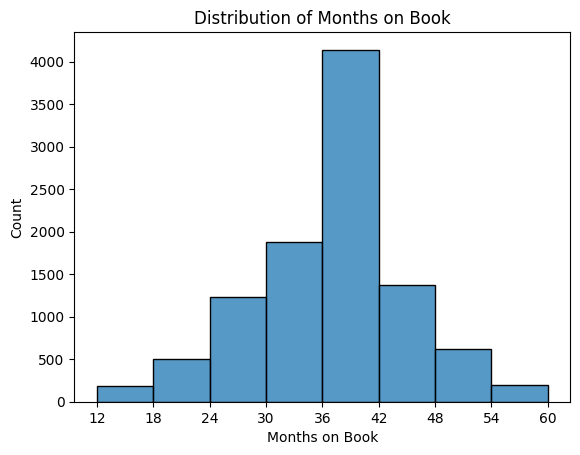

In [240]:
#Exploring the Months_on_book distribution defining the custom bin range based on the min and max age value found in the column
sns.histplot(x='Months_on_book',
             binrange=(12, 60),
             binwidth=6,
             data=data_df)
plt.xticks(range(12, 61, 6))
plt.xlabel('Months on Book')
plt.ylabel('Count')
plt.title('Distribution of Months on Book')
plt.show()

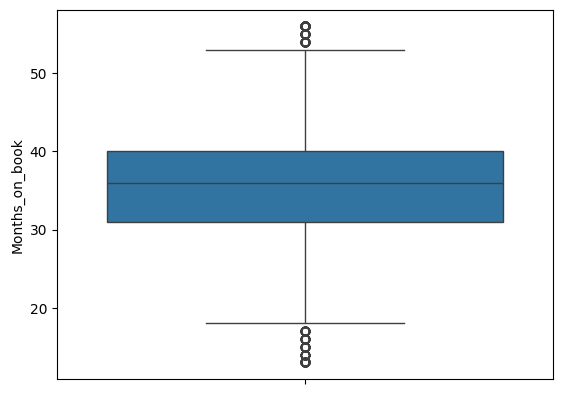

In [241]:
# create box plot for Months_on_book column
sns.boxplot(y=data_df['Months_on_book'])
plt.show()

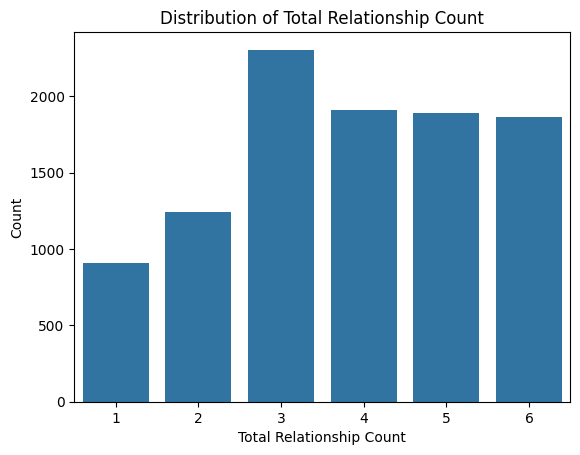

In [242]:
sns.countplot(x='Total_Relationship_Count', data=data_df)
plt.xlabel('Total Relationship Count')
plt.ylabel('Count')
plt.title('Distribution of Total Relationship Count')
plt.show()

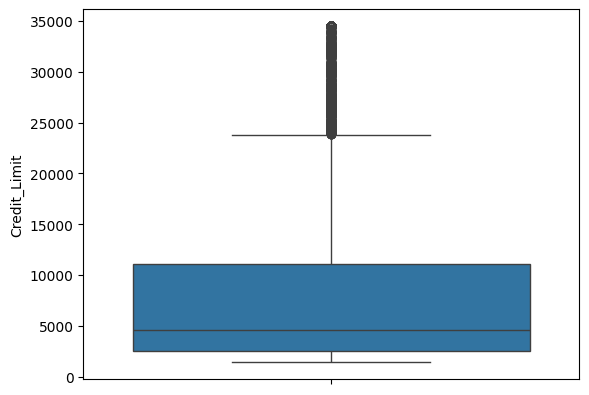

In [243]:
# Exploring the distribution of data by drawing box plot for Credit_Limit column to check for data center and outliers
sns.boxplot(y=data_df['Credit_Limit'])
plt.show()

**Observation**

We can see from the box plot the big concentration of the outliers between 25K to 35K because of which we saw earlier in the statistical summary that mean was much higher than the median and data was right skewed

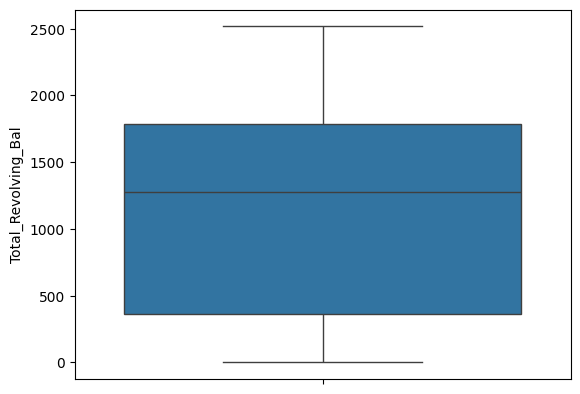

In [244]:
sns.boxplot(y=data_df['Total_Revolving_Bal'])
plt.show()

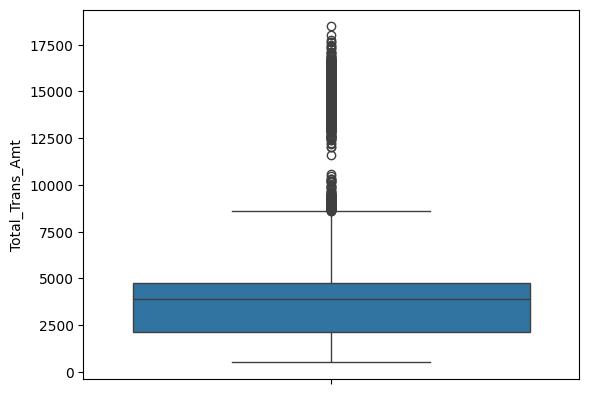

In [245]:
sns.boxplot(y=data_df['Total_Trans_Amt'])
plt.show()

**Observation**

We can see from the box plot the outliers between 10K to 18K because of which we saw earlier in the statistical summary that data was somewhat right skewed

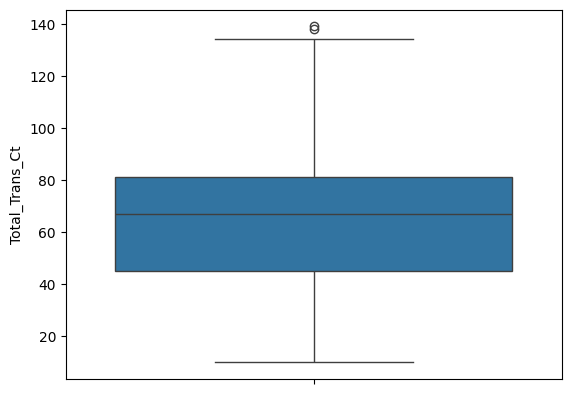

In [246]:
sns.boxplot(y=data_df['Total_Trans_Ct'])
plt.show()

<Axes: xlabel='Total_Trans_Ct', ylabel='Total_Trans_Amt'>

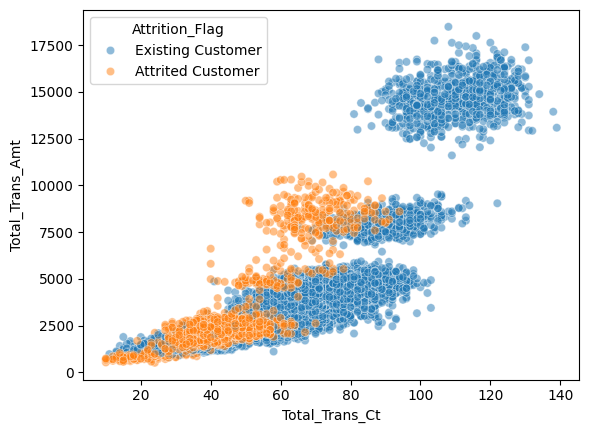

In [247]:
# Exploring the relationship between Total Txn Count and Total Transaction Amount features for the existing and attrited customers.
sns.scatterplot(data=data_df, x='Total_Trans_Ct', y='Total_Trans_Amt', hue='Attrition_Flag', alpha=0.5)

Observation

The scatter plot clearly shows the trend for Transaction count and transaction amount with the txn count and amount concentrated more on the lower side of Count and Amount for Attrited Customers. This shows that customers who are at risk of attrition will lower their transaction on the card before leaving the service.

<Axes: xlabel='Attrition_Flag', ylabel='Total_Trans_Amt'>

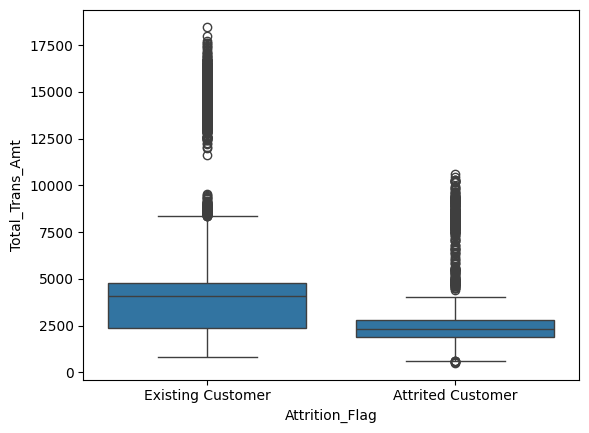

In [248]:
# Comparing the statistical summary of Total Transaction Amount based on the target variable Attrition_Flag
sns.boxplot(data=data_df, x='Attrition_Flag', y='Total_Trans_Amt')

**Observation**

As we saw earlier in the scatter plot, this box plot confirms that the customers who are attrited have the lower median and other stats compared to the existing customer

<Axes: xlabel='Attrition_Flag', ylabel='Total_Trans_Ct'>

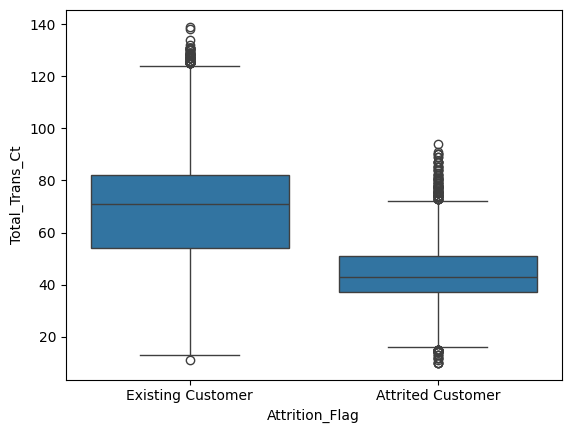

In [249]:
# Comparing the statistical summary of Total Transaction Count based on the target variable Attrition_Flag
sns.boxplot(data=data_df, x='Attrition_Flag', y='Total_Trans_Ct')

**Observation**

As we saw earlier in the scatter plot, this box plot confirms that the customers who are attrited have the lower median and other stats for transaction count compared to the existing customer

<Axes: xlabel='Months_on_book', ylabel='Total_Trans_Amt'>

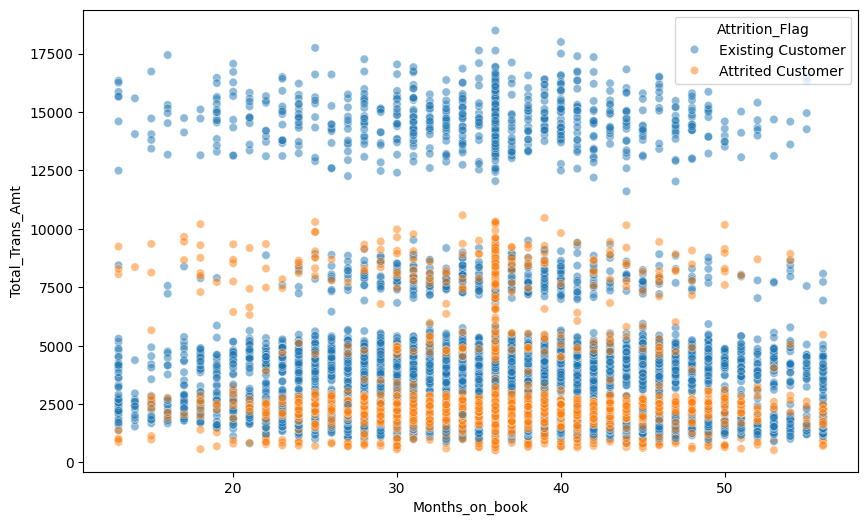

In [250]:
# Exploring the relationship between Total Transaction amount and Months on Book
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data_df, y='Total_Trans_Amt', x='Months_on_book', hue='Attrition_Flag', alpha=0.5)

Observations

*   We can clearly see from this scatter plot that customers who are spending upward of 12k on the card are happy with the services and are not likely to churn.
*   The customers most likely to attrite and more likely to spend less on the card. We see the concentration. of orange dots across monts from 20 to 50 around 1500 to 2500 range.
* From the scatter plot it looks like the maximum churn happens at around 36 months. Customers leave the service most at 3 years.



In [251]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Attrition_Flag            10127 non-null  object 
 1   Customer_Age              10127 non-null  int64  
 2   Gender                    10127 non-null  object 
 3   Dependent_count           10127 non-null  int64  
 4   Education_Level           10127 non-null  object 
 5   Marital_Status            10127 non-null  object 
 6   Income_Category           10127 non-null  object 
 7   Card_Category             10127 non-null  object 
 8   Months_on_book            10127 non-null  int64  
 9   Total_Relationship_Count  10127 non-null  int64  
 10  Months_Inactive_12_mon    10127 non-null  int64  
 11  Contacts_Count_12_mon     10127 non-null  int64  
 12  Credit_Limit              10127 non-null  float64
 13  Total_Revolving_Bal       10127 non-null  int64  
 14  Avg_Op

<Axes: xlabel='Attrition_Flag', ylabel='Contacts_Count_12_mon'>

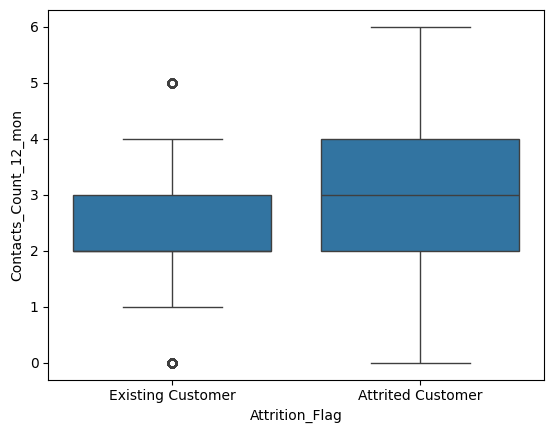

In [252]:
# Exploring the statistical summary of the Contact Counts in 12 mons based on the target variable Attrited_Flag
sns.boxplot(data=data_df, x='Attrition_Flag', y='Contacts_Count_12_mon')

In [253]:
data_df.query('Attrition_Flag == "Existing Customer"')['Contacts_Count_12_mon'].median()

np.float64(2.0)

**Observation**

The box plot shows that the median for Attrited customer which is 3 is higher than the existing customer which is 2. This shows the relationship between the customers that have higher contact because of complaints or other service related calls and the attrition flag.

<Axes: xlabel='Attrition_Flag', ylabel='Avg_Utilization_Ratio'>

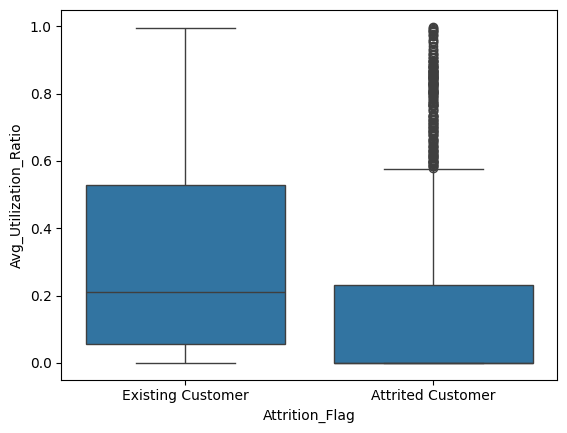

In [254]:
#Exploring the statistical summary of the Avg Utilization Ration based on the target variable Attrited_Flag
sns.boxplot(data=data_df, x='Attrition_Flag', y='Avg_Utilization_Ratio')

In [255]:
data_df.query('Attrition_Flag == "Attrited Customer"')['Avg_Utilization_Ratio'].median()

np.float64(0.0)

**Observation**

The box plot shows that the median for Attrited customer which is 0.0 is lower than the existing customer which is 0.2. This shows the relationship between the customers that have lower Avg Utilization Ratio and the attrition flag.

<Axes: xlabel='Avg_Utilization_Ratio', ylabel='Density'>

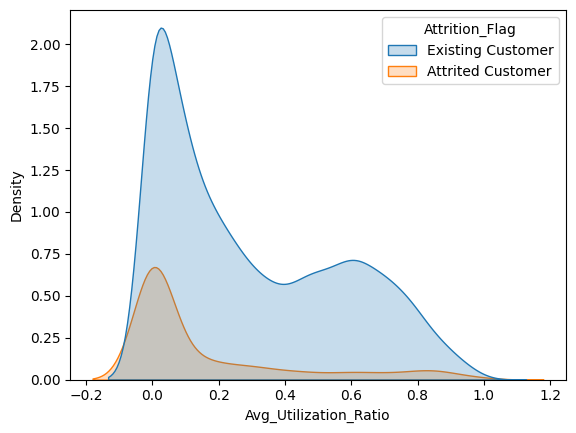

In [256]:
# Exploring the KDE plot for the Avg Utilization Ratio based on the target variable
sns.kdeplot(data=data_df, x='Avg_Utilization_Ratio', hue='Attrition_Flag', fill=True)

**Observation**

The KDE plot clearly shows that for the majority of Attrited Customers the Avg Utilization ratio drops to zero before they leave the service.

In [257]:
print(data_df['Credit_Limit'].min())
print(data_df['Credit_Limit'].max())

1438.3
34516.0


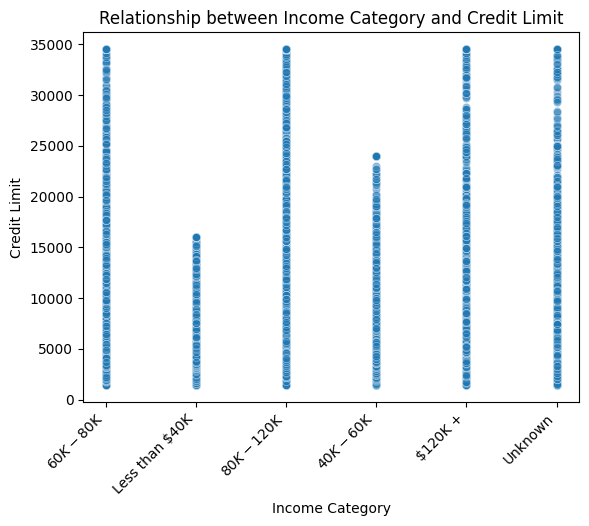

In [258]:
# Exploring the relationship between Income category and the credit limit
sns.scatterplot(data=data_df, x='Income_Category', y='Credit_Limit', alpha=0.5)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Income Category')
plt.ylabel('Credit Limit')
plt.title('Relationship between Income Category and Credit Limit')
plt.show()

**Observation**

We see a partial relationship between income category and Credit limit. We see that at the lower level the income category has a definite impact on the credit limit. For the income upto 40k the max credit limit is 15000 and for the 40k to 60k it is 25000. But beyond 60k, the income category does not seems to have impact on the credit limit and we see from 60k to 120k+, all income categories having credit limit going all the way to 35k.

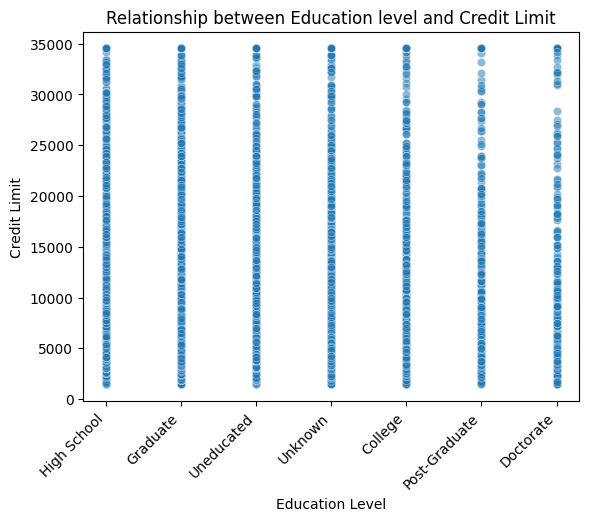

In [259]:
# Exploring the relationship between Education level and Credit limit
sns.scatterplot(data=data_df, x='Education_Level', y='Credit_Limit', alpha=0.5)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Education Level')
plt.ylabel('Credit Limit')
plt.title('Relationship between Education level and Credit Limit')
plt.show()

**Observation**

There does not seems to be any impact of the education level on the credit limit.

**Feature Engineering**

Based on the data analysis and observations, we need to deal with the following to improve the data quality

*   Identify strategy to handle the Unknown category for Income Category, Education level, Marital Status columns
*   Derive new features from the dataset which can provide more insight into the customer behavior



**Handling Unknown Category in the Categorical Columns**

There are three categorical columns for which we need to handle the Unknown category which is created for the missing data. The following strategy has been identified for the each of the columns


*   For Income Category column, we can impute the value for the rows with value Unknown by computing the median of the Credit limit for different Income categories and then use the Credit Limit value in the Unknown Income Category row to impute the Income Category based on the credit limit range we create based on the median credit limit we observe. This is because as we had seen earlier there is a relationship between credit limit and income levels.
*   For Education level and Marital status columns, we will keep the Unknown category as an explicit category since it is harder to cross reference and impute the values based on other features. However the type of the columns will be changed from Object to Category. Changing the data type from Object to Category gives a huge memory optimizations since pandas internally creates a reference map for these categories with integer to string mapping and then store the memory efficient integers instead of strings for all the rows.



In [260]:
# Calculatin the median for credit limit for each Income Category
data_df.groupby('Income_Category')['Credit_Limit'].median()

Income_Category
$120K +           18442.0
$40K - $60K        3682.0
$60K - $80K        7660.0
$80K - $120K      12830.0
Less than $40K     2766.0
Unknown            6380.0
Name: Credit_Limit, dtype: float64

In [261]:
data_df['Income_Category'].value_counts()

Income_Category
Less than $40K    3561
$40K - $60K       1790
$80K - $120K      1535
$60K - $80K       1402
Unknown           1112
$120K +            727
Name: count, dtype: int64

In [262]:
# Method which takes as input the row and return the income category based on the credit limit profiles
def impute_income_category(row):
    # Only process rows where Income is missing/Unknown
    if row["Income_Category"] == "Unknown":
        limit = row["Credit_Limit"]

        # Define mapping boundaries based on the median profiles we calucluated above using groupby
        if limit >= 15000:
            return "$120K +"
        elif limit >= 10000:
            return "$80K - $120K"
        elif limit >= 5000:
            return "$60K - $80K"
        elif limit >= 3500:
            return "$40K - $60K"
        else:
            return "Less than $40K"

    # If it's already known, keep it as-is
    return row["Income_Category"]


# Apply the conditional mapping function to the DataFrame
data_df["Income_Category"] = data_df.apply(impute_income_category, axis=1)

# Verify that 'Unknown' values are gone from the Income column
print("\n--- Cleaned Income Category Counts ---")
print(data_df["Income_Category"].value_counts())



--- Cleaned Income Category Counts ---
Income_Category
Less than $40K    3884
$40K - $60K       1926
$60K - $80K       1689
$80K - $120K      1682
$120K +            946
Name: count, dtype: int64


In [263]:
# Leave 'Unknown' intact for Education Level and Marital Status. Convert the datatype of the columns from Object to Category except target variable Attrition_Flag
data_df["Education_Level"] = data_df["Education_Level"].astype("category")
data_df["Marital_Status"] = data_df["Marital_Status"].astype("category")
data_df["Income_Category"] = data_df["Income_Category"].astype("category")
data_df["Gender"] = data_df["Gender"].astype("category")
data_df["Card_Category"] = data_df["Card_Category"].astype("category")

In [264]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Attrition_Flag            10127 non-null  object  
 1   Customer_Age              10127 non-null  int64   
 2   Gender                    10127 non-null  category
 3   Dependent_count           10127 non-null  int64   
 4   Education_Level           10127 non-null  category
 5   Marital_Status            10127 non-null  category
 6   Income_Category           10127 non-null  category
 7   Card_Category             10127 non-null  category
 8   Months_on_book            10127 non-null  int64   
 9   Total_Relationship_Count  10127 non-null  int64   
 10  Months_Inactive_12_mon    10127 non-null  int64   
 11  Contacts_Count_12_mon     10127 non-null  int64   
 12  Credit_Limit              10127 non-null  float64 
 13  Total_Revolving_Bal       10127 non-null  int6

**Creating New Columns from the dataset**

As part of feature engineering, creating the following two new columns

* Avg_Transaction_Size - This column is calculated by dividing the Total_Trans_Amt with Total_Trans_Ct to create the column to get insight into the average spending of the customer per transaction   
* Unused_Credit_Buffer - This column is calculated by subtracting the Total_Revolving_Bal from Credit_Limit to create the column to get insight into the credit usage of the customer.



In [265]:

# Calculate average transaction size
data_df["Avg_Transaction_Size"] = data_df["Total_Trans_Amt"] / data_df["Total_Trans_Ct"]

# Calculate credit utilization
data_df["Unused_Credit_Buffer"] = data_df["Credit_Limit"] - data_df["Total_Revolving_Bal"]

# Handle a potential mathematical edge case (division by zero)
data_df["Avg_Transaction_Size"] = data_df["Avg_Transaction_Size"].fillna(0)


In [266]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Attrition_Flag            10127 non-null  object  
 1   Customer_Age              10127 non-null  int64   
 2   Gender                    10127 non-null  category
 3   Dependent_count           10127 non-null  int64   
 4   Education_Level           10127 non-null  category
 5   Marital_Status            10127 non-null  category
 6   Income_Category           10127 non-null  category
 7   Card_Category             10127 non-null  category
 8   Months_on_book            10127 non-null  int64   
 9   Total_Relationship_Count  10127 non-null  int64   
 10  Months_Inactive_12_mon    10127 non-null  int64   
 11  Contacts_Count_12_mon     10127 non-null  int64   
 12  Credit_Limit              10127 non-null  float64 
 13  Total_Revolving_Bal       10127 non-null  int6

In [267]:
mapping = {'Existing Customer': 0, 'Attrited Customer': 1}
data_df['Attrition_Flag'] = data_df['Attrition_Flag'].map(mapping)

In [268]:
data_df['Attrition_Flag'].value_counts(normalize=True)

Attrition_Flag
0    0.83934
1    0.16066
Name: proportion, dtype: float64

In [269]:
# Dropping the target variable from the X and assigning to y
X = data_df.drop(columns = ['Attrition_Flag'])
y = data_df['Attrition_Flag']

In [270]:
# Spliting dataset with Training data as 70% and Test data as 30%
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, test_size=0.3)

In [271]:
# Checking to ensure that the test data has the both the classes in the same proportion as original dataset for target variable
y_test.value_counts(normalize=True)

Attrition_Flag
0    0.836788
1    0.163212
Name: proportion, dtype: float64

In [272]:
data_df['Education_Level'].unique()

['High School', 'Graduate', 'Uneducated', 'Unknown', 'College', 'Post-Graduate', 'Doctorate']
Categories (7, object): ['College', 'Doctorate', 'Graduate', 'High School', 'Post-Graduate', 'Uneducated', 'Unknown']

**Creating Preprocessor for the Columns**


*   Numerical columns are transformed using StandardScaler
*   Categorical columns except Education Level are transformed using OnHotEncoder
* Education_Level column is transformed using OrdinalEncoder with the custom defined order of the education levels.





In [273]:
categorical_columns = X.select_dtypes(include=['object','category']).columns.tolist()
categorical_columns.remove('Education_Level')
numerical_columns = X.select_dtypes(include=['float64', 'int64']).columns.tolist()
edu_order = [
     'Uneducated', 'Unknown', 'High School', 'College',
    'Graduate', 'Post-Graduate', 'Doctorate'
]
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_columns),
        ('cat', OneHotEncoder(drop='first'), categorical_columns),
        ('edu', OrdinalEncoder(categories=[edu_order]), ['Education_Level'])
    ]
)

**Building LogisticRegression Model for the baseline**

                Model  Training Time  Train Accuracy  Test Accuracy
0  LogisticRegression       0.101707        0.862302       0.856532

Classification Results for further inquiry
              precision    recall  f1-score   support

           0       0.97      0.86      0.91      2543
           1       0.54      0.86      0.66       496

    accuracy                           0.86      3039
   macro avg       0.75      0.86      0.79      3039
weighted avg       0.90      0.86      0.87      3039



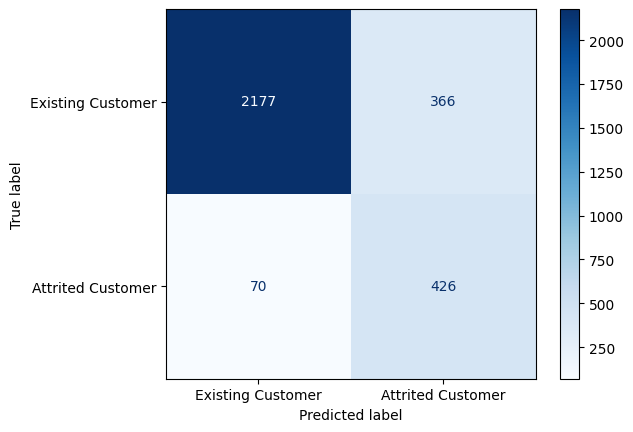

In [274]:
# Building the basic Logistic Regression model with setting class_weight=balanced since we have a very
# imbalanced target classes with Existing Customer as 86% and Attrited Customer as 14%. Without setting this parameter, this model will be
# completely useless since it will pick always from Existing Customer class
lr_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced'))
])
start_time = time.time()
lr_pipe.fit(X_train, y_train)
end_time = time.time()
training_time = end_time - start_time
# Find the accuracy of the model on train and test data sets
y_pred_train = lr_pipe.predict(X_train)
y_pred_test = lr_pipe.predict(X_test)
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)
lr_results = []
lr_results.append(['LogisticRegression', training_time, train_accuracy, test_accuracy])

lr_results_df = pd.DataFrame(lr_results, columns=['Model', 'Training Time', 'Train Accuracy', 'Test Accuracy'])
print(lr_results_df)
print()
print("Classification Results for further inquiry")
print(classification_report(y_test, y_pred_test))
lr_model = lr_pipe.named_steps['classifier']
# Exploring the confusion matrix
disp = ConfusionMatrixDisplay.from_estimator (
  lr_pipe, X_test, y_test,
  display_labels=['Existing Customer', 'Attrited Customer'],
  cmap=plt.cm.Blues)
plt.show()

In [275]:
# Optimizing the Logistic Regression Classifier using GridSearchCV to improve the quality of results

models = {
    'logistic_regression': (LogisticRegression(class_weight='balanced'), {'classifier__C': [0.01, 0.1, 1, 10, 100]}),
    'ridge': (RidgeClassifier(class_weight='balanced'), {'classifier__alpha': [0.01, 0.1, 1, 10, 100]})
}
model_results = []
for model_name, (model, param_grid) in models.items():
    model_pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    grid_search = GridSearchCV(model_pipe, param_grid, cv=5, scoring='recall')
    start_time = time.time()
    grid_search.fit(X_train, y_train)
    fit_time = (time.time() - start_time) / len(grid_search.cv_results_['mean_fit_time'])
    print(grid_search.best_params_)
    y_pred_train = grid_search.predict(X_train)
    y_pred_test = grid_search.predict(X_test)
    train_accuracy = accuracy_score(y_train, y_pred_train)
    test_accuracy = accuracy_score(y_test, y_pred_test)
    precision = precision_score(y_test, y_pred_test,pos_label=1)
    recall = recall_score(y_test, y_pred_test, pos_label=1)
    model_results.append([model_name, fit_time, train_accuracy, test_accuracy, precision, recall])

model_results_df = pd.DataFrame(model_results, columns=['Model', 'Training Time', 'Train Accuracy', 'Test Accuracy', 'Precision', 'Recall'])
model_results_df

{'classifier__C': 0.1}
{'classifier__alpha': 100}


,Model,Training Time,Train Accuracy,Test Accuracy,Precision,Recall
0,logistic_regression,0.530504,0.861456,0.857519,0.540127,0.854839
1,ridge,0.267785,0.861174,0.857848,0.540609,0.858871


**Interpreting Results for Baseline Model**

We used LogisticRegression as the model to baseline results. Interpreting the results of the Logistic Regression model with only setting the class_weigth='balalnced' and no other hyperparameter configuration we observe the following results
* The training accuracy (86.2%) and test accuracy of (85.7%) are very close which indicates that Logistic Regression model is generalizing on the unseen data and there is no overfitting
* Since the dataset is highly imbalanced with the majority class as 84% and minority class as 16%, a completely random model which simply guesses majority class every time will still have accuracy score of 84%. Our Logistic Regression model has accuracy of 86% it is performing better than the dummy model. However we need to look at other metrics like Recall and Precision to get deeper insight into the model performance.
* For the majority class Existing Customers(0), of all the instances that model labelled as 0, we see the Precision score of 97% which indicates very high accuracy of correctly predicting the majority class. The Recall score for majority class is 86% which means it was able to find 86% of all the actual majority class (Existing Customer) instances
* For the minority class Attrited Customer(1) which has a more critical focus since our problem is to predict the attrition, the Recall score is 86% which is phenomenal result since we are able to find 86% of the instances of the minority class(1) in an highly imbalanced dataset. However looking at the Precision score for the minority class(1) we see it as 54% which means of all the instances it flagging as attrition only 54% are actually true creating large False Positives. This can be problematic since it is generating lot of false alarms and we need to find ways to increase the Precision for the minority class.
* As part of baselining the results, Logistic Regression and Ridge Classifier with GridSearchCV was also tried to find the best parameters for the regularization. The results for both Logistic Regression and Ridge Classifier using GridSearch CV were almost identical to Logistic Regression as can be seen above.